In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('../data/superstore.csv', encoding='latin-1')
print(df.head())
print(df.shape)
print(df.info())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

Preguntas de negocio:
- 1- ¿Cuál es el producto más rentable? ¿Qué margen tiene?
- 2- ¿Qué regiones son las más rentables? ¿Qué productos son los top 3 de las tiendas más rentables? ¿Hay algún patron que se repita?
- 3- ¿Los descuentos grandes siempre generan pérdidas? ¿A partir de algún porcentaje de descuento siempre se pierde? ¿Cual es el descuento que más profit genera?
- 4- ¿Cual es el segmento de cliente más rentable? ¿En qué proporción? ¿Merece la pena centrarse más en ese segmento y eliminar el otro o conviene mantener ambos?
- 5- ¿Hay algún producto que no merezca la pena mantener? ¿Alguno que no se venda casi o que casi no de beneficios?

In [14]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


A partir de un describe del data frame se pueden observar varias cuestiones importantes:
- Observamos profits de -6599, lo que sugiere pérdidas importantes que habría que revisar. 
- Encontramos tambien que hay descuentos de hasta el 80%, que podrían tener relación con el punto anterior. 
- La rentabilidad varía muchísimo ya que a pesar de haber un profit medio de 28, su desviación es de 234. 
- También vemos que se obtienen beneficios de hasta 8399 por lo que podría ser un punto interesante a potenciar. 

In [15]:
#¿Cuál es el producto más rentable? 
cat_mas_rentables = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(cat_mas_rentables)
subcat_mas_rentables = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
print(subcat_mas_rentables)

#¿Qué regiones son las más rentables? 
regiones_mas_rentables = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(regiones_mas_rentables)

#Media de profit en funcion del descuento?
descuento_profit = df.groupby('Discount')['Profit'].mean().sort_values(ascending=False)
print(descuento_profit)




Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64
Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64
Discount
0.10     96.055074
0.00     66.900292
0.15     27.288298
0.20     24.702572
0.60    -43.077212
0.30    -45.679636
0.32    -88.560656
0.70    -95.874060
0.80   -101.796797
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
Name: Profit, dtype:

In [16]:
ventas_mesas = df[df['Sub-Category'] == 'Tables']['Sales'].sum()
ventas_sillas = df[df['Sub-Category'] == 'Chairs']['Sales'].sum()
print(f"Ventas de mesas: {ventas_mesas}")
print(f"Ventas de sillas: {ventas_sillas}")
print(f"Ratio de sillas por mesa: {ventas_sillas / ventas_mesas:.2f}")
df_mesas_sillas = df[df['Sub-Category'].isin(['Tables', 'Chairs'])]
print(f"Correlacion mesas-sillas: {df_mesas_sillas['Sales'].corr(df_mesas_sillas['Profit']):.2f}")


Ventas de mesas: 206965.532
Ventas de sillas: 328449.103
Ratio de sillas por mesa: 1.59
Correlacion mesas-sillas: 0.21


In [17]:
ratio_west_central = regiones_mas_rentables['West'] / regiones_mas_rentables['Central']
print(f"Ratio de rentabilidad entre West y Central: {ratio_west_central:.2f}")

Ratio de rentabilidad entre West y Central: 2.73


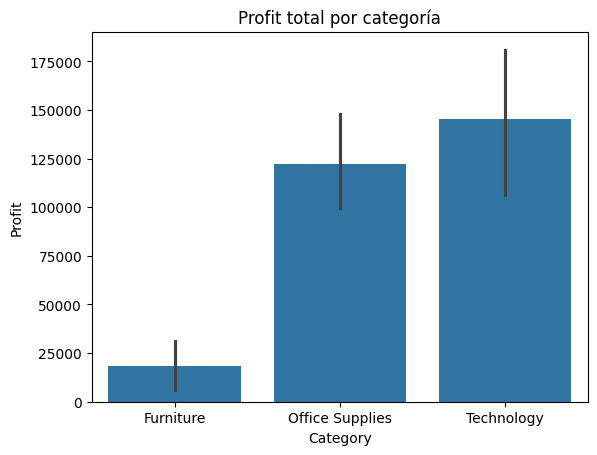

In [18]:

# 1. Profit por categoría
sns.barplot(data=df, x='Category', y='Profit', estimator=sum)
plt.title('Profit total por categoría')
plt.show()

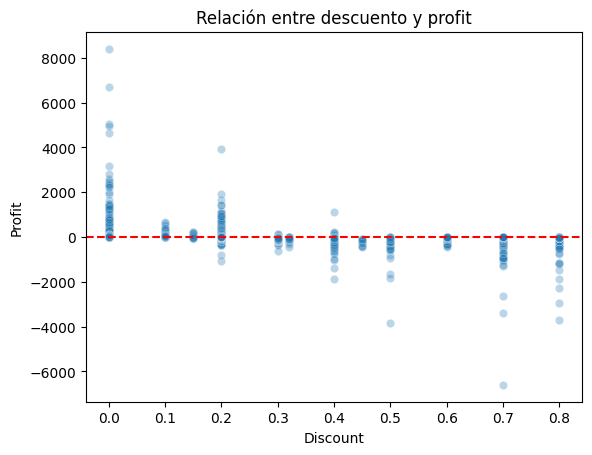

In [19]:
# 2. Descuento vs Profit 
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.3)
plt.title('Relación entre descuento y profit')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

# Primeros insights
- Sobre los tipos de producto y productos
La venta de productos tecnológicos resulta la más rentable del negocio, siendo siempre rentables. Por otro lado la venta de mobiliario es la que menos beneficios aporta a la empresa, sobre todo debido a que la venta de mesas genera una pérdida considerable. Las mesas representan la mayor fuente de pérdidas con -17.725€ de profit total por lo que se debería estudiar la eliminación de esta vertical o el estudio más en profundidad de si es el tipo de producto en general que no es propenso a grandes beneficios, o si la categoría se ve especialmente mermada por las pérdidas en mesas. Se observa que tampoco es tan rentable la venta de sillas como para suplir las pérdidas en mesas o estanterías. 

- Sobre los descuentos y los beneficios
Se observa que de media, los peores descuentos son los del 40-45%, y que a partir del 20-30% la media de beneficios es negativa, es decir, hay pérdidas. Observando un poco más esta relación, vemos que a partir del 40% en casi ningún caso se obtiene rentabilidad, llegando hasta grandes pérdidas para descuentos del 70 y 80%. También vemos que a pesar de ser los descuentos del 45 y 50% los que peor media ofrecen, no son los que obtienen más peridas individuales por lo que lo se achaca a un mayor volúmen en la cantidad de descuentos de este tipo. Debido a que para los descuentos más altos la media no es tan mala, podría deberse a pérdidas controladas por exceso de stock o la necesidad de vender rápidamente ciertos productos. Tras todo esto, lo que está claro es que a partir de descuentos del 40% ya no se genera ningún tipo de rentabilidad asi que se podría estudiar la posibilidad de eliminar este tipo de descuentos u ofrecer otras ofertas más competentes que no terminen en tantas pérdidas. 

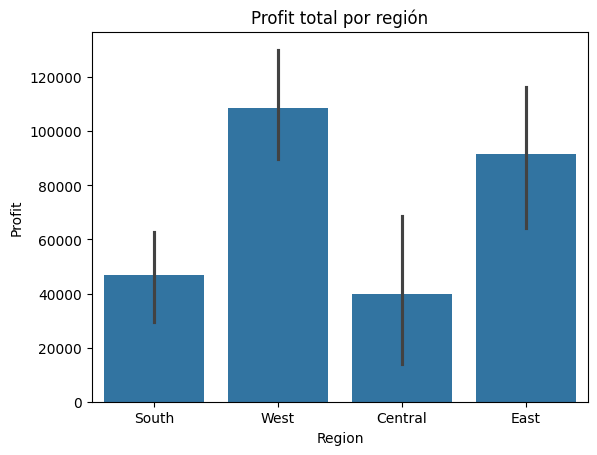

In [20]:
# Profit por región
sns.barplot(data=df, x='Region', y='Profit', estimator=sum)
plt.title('Profit total por región')
plt.show()

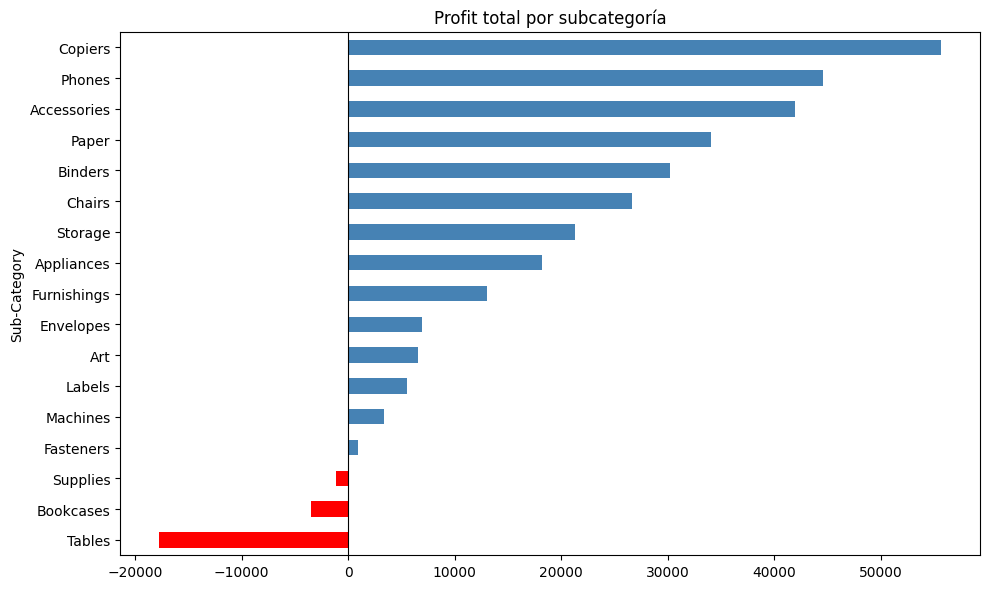

In [21]:
# Profit por subcategoría

profit_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values()
profit_subcat.plot(kind='barh', figsize=(10,6), color=profit_subcat.apply(lambda x: 'red' if x < 0 else 'steelblue'))
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Profit total por subcategoría')
plt.tight_layout()
plt.show()

In [29]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

df['Order Date'].dtype
print(df.info())
print(df['Year'].unique())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

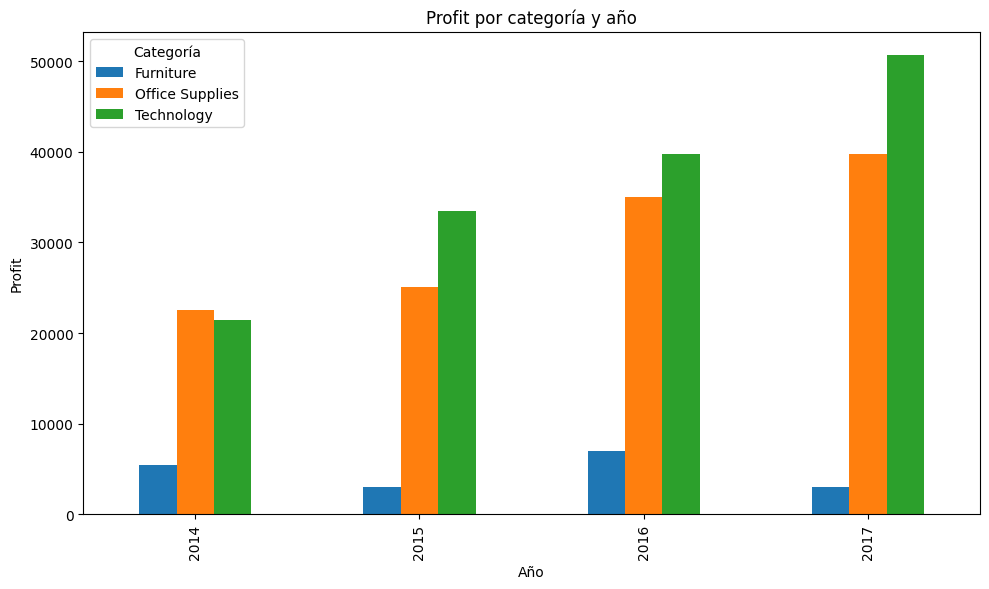

In [ ]:
profit_por_año = df.groupby(['Year', 'Category'])['Profit'].sum().unstack()

profit_por_año.plot(kind='bar', figsize=(10,6))
plt.title('Profit por categoría y año')
plt.xlabel('Año')
plt.ylabel('Profit')
plt.legend(title='Categoría')
plt.tight_layout()
plt.show()

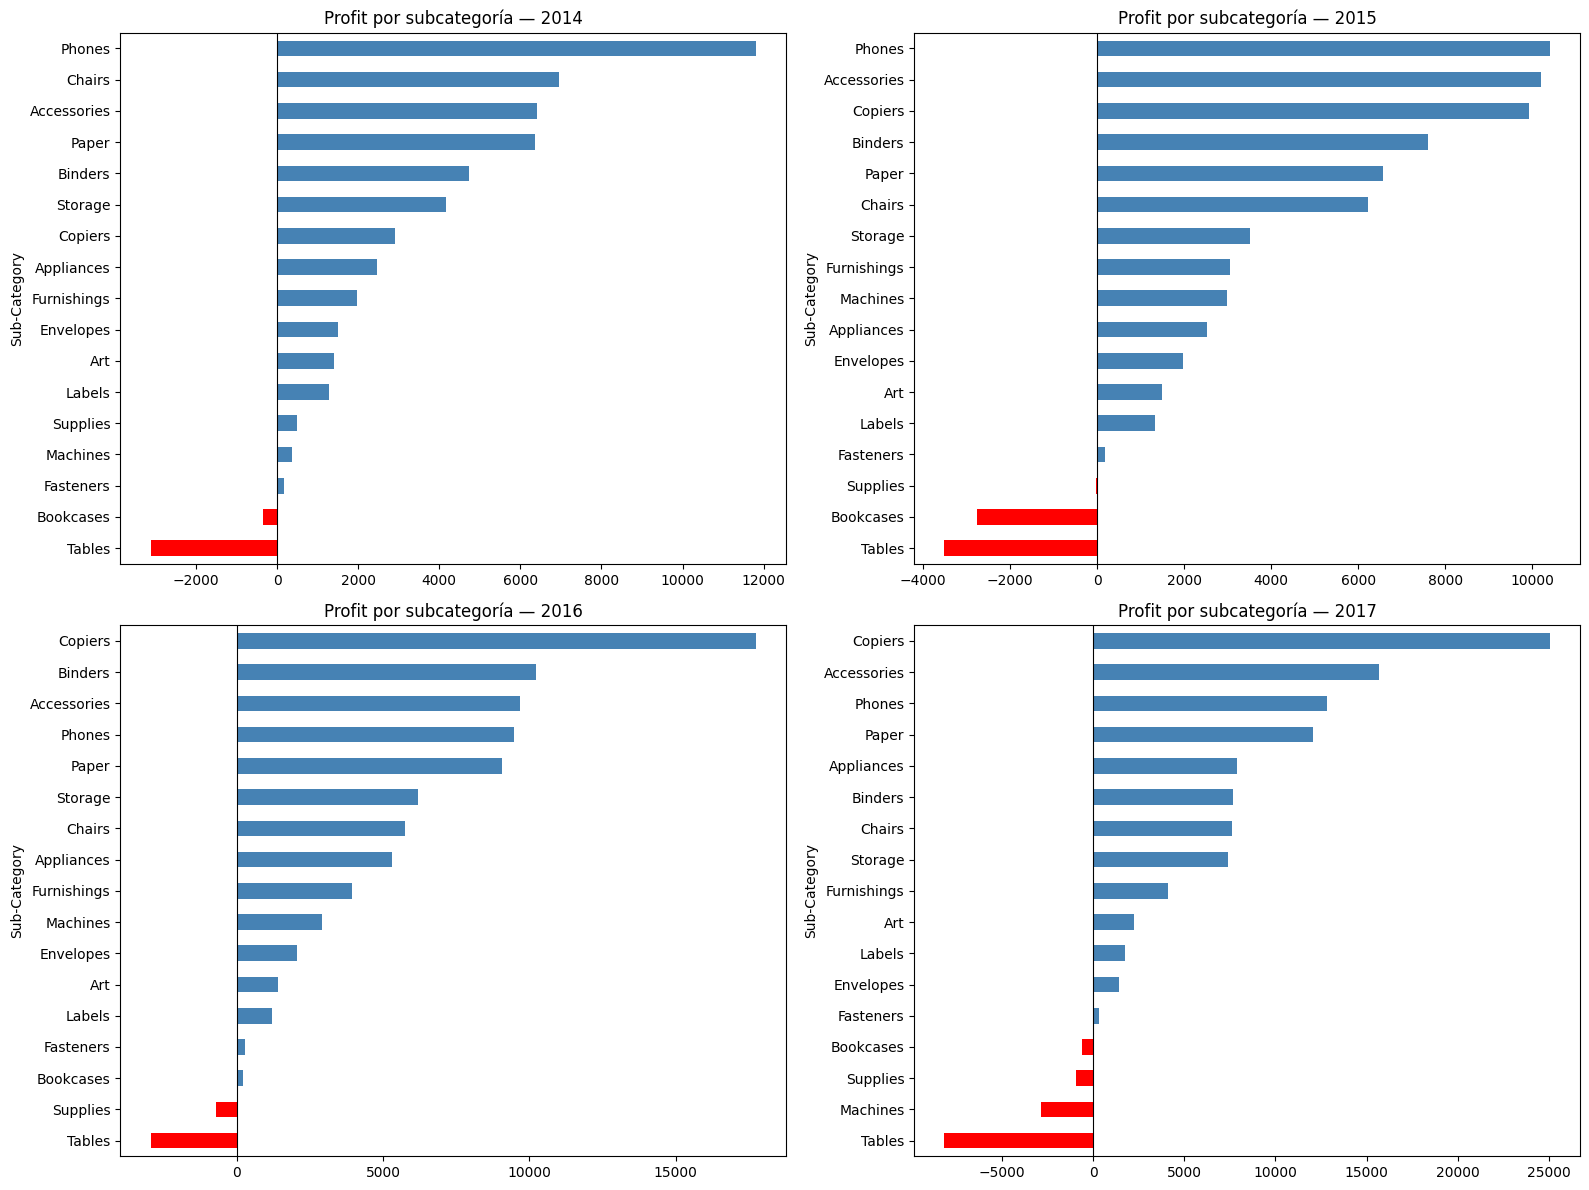

In [50]:
años = df['Year'].unique()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, year in enumerate(sorted(años)):
    data = df[df['Year'] == year].groupby('Sub-Category')['Profit'].sum().sort_values()
    colors = ['red' if x < 0 else 'steelblue' for x in data]
    data.plot(kind='barh', ax=axes[i], color=colors)
    axes[i].axvline(x=0, color='black', linewidth=0.8)
    axes[i].set_title(f'Profit por subcategoría — {year}')

plt.tight_layout()
plt.show()

# Primeros insights
- Sobre los tipos de producto y productos
La venta de productos tecnológicos resulta la más rentable del negocio, siendo siempre rentables. Por otro lado la venta de mobiliario es la que menos beneficios aporta a la empresa, sobre todo debido a que la venta de mesas genera una pérdida considerable. Las mesas representan la mayor fuente de pérdidas con -17.725€ de profit total por lo que se debería estudiar la eliminación de esta vertical o el estudio más en profundidad de si es el tipo de producto en general que no es propenso a grandes beneficios, o si la categoría se ve especialmente mermada por las pérdidas en mesas. Se observa que tampoco es tan rentable la venta de sillas como para suplir las pérdidas en mesas o estanterías. 

- Sobre los descuentos y los beneficios
Se observa que de media, los peores descuentos son los del 40-45%, y que a partir del 20-30% la media de beneficios es negativa, es decir, hay pérdidas. Observando un poco más esta relación, vemos que a partir del 40% en casi ningún caso se obtiene rentabilidad, llegando hasta grandes pérdidas para descuentos del 70 y 80%. También vemos que a pesar de ser los descuentos del 45 y 50% los que peor media ofrecen, no son los que obtienen más peridas individuales por lo que lo se achaca a un mayor volúmen en la cantidad de descuentos de este tipo. Debido a que para los descuentos más altos la media no es tan mala, podría deberse a pérdidas controladas por exceso de stock o la necesidad de vender rápidamente ciertos productos. Tras todo esto, lo que está claro es que a partir de descuentos del 40% ya no se genera ningún tipo de rentabilidad asi que se podría estudiar la posibilidad de eliminar este tipo de descuentos u ofrecer otras ofertas más competentes que no terminen en tantas pérdidas. 

- Tras hacer un análisis temporal se puede observar también que las mesas, a lo largo de los 4 años de registros, han generado pérdidas sistemáticamente. También las estanterías, que están en pérdidas a nivel general han estado oscilando entre las pérdidas y los beneficios nulos. En este análisis temporal, el insight más clave es, sin duda, la detección de un cambio de tendencia en los beneficios de las máquinas, cayendo hatsa opérdidas en el último año. 